# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [7]:
print ("Plans:")
print(plans.head())

Plans:
  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  


In [8]:
print("\nUsers:")
print(users.head())


Users:
   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [9]:
print("\nUsage:")
print(usage.head())


Usage:
   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [10]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [11]:
print("plans", plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes
plans None


In [12]:
print("users", users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB
users None


In [13]:
print("usage", usage.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB
usage None


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [14]:
# cantidad de nulos para users
print("Valores nulos en users:")
print(users.isna().sum())

Valores nulos en users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64


In [15]:
print("\nProporción de nulos en usage:")
print(usage.isna().mean())


Proporción de nulos en usage:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
  
- En el dataset users, la columna city tiene aproximadamente 11% de valores nulos, por lo que se podría investigar si es posible imputarlos usando otra información del usuario o dejarlos como nulos si no afectan el análisis.
  
- La columna churn_date tiene alrededor de 84% de valores nulos, pero esto parece lógico porque muchos usuarios probablemente no han cancelado el servicio; se recomienda conservarla y considerar los nulos como “usuarios activos”.
  
- En el dataset usage, la columna date tiene solo 0.1% de nulos, por lo que podría imputarse o eliminarse fácilmente sin afectar el análisis.
  
- La columna duration tiene aproximadamente 55% de nulos y la columna length cerca de 44%; esto probablemente ocurre porque duration aplica solo a llamadas y length solo a mensajes. Se recomienda mantener los nulos porque representan tipos de uso diferentes y no necesariamente errores.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [16]:
# explorar columnas numéricas de users
print(users[['user_id', 'age']].describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id`parece funcionar correctamente como identificador, ya que los valores estan dentro de un rango continuo y no se observan anomalias
- La columna `age` presenta un posible valor invalido o sentinel (-999), ya que no representa una edad real. Se recomienda inestigar y posiblemente reemplazarlo por un valor nulo

In [17]:
# explorar columnas numéricas de usage
print(usage[['id', 'user_id', 'duration', 'length']].describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`funcionan como identificadores y no muestran valores inconsistentes
- Las columna 'duration' tiene valores desde 0 hasta 120 minutos; el valor 0 podria representar llamadas fallidas o muy cortas y seria importante validar su significado
- la columna 'lenght' presenta una gran dispersion y un valor maximo muy alto (1490), por lo que conviene revisar posibles outliers

In [18]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\nValores únicos de {col}:")
    print(users[col].value_counts(dropna=False).head(10))


Valores únicos de city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos de plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` contiene ciudades validas, pero tambien presenta valores nulos y el simbolo "?", que probablemente representa datos faltantes o invalidos
- La columna `plan` solamente contiene categorias "basico" y "premium" lo cual coincide con los planes esperados

In [19]:
# explorar columna categórica de usage
columnas_usage = ['type'] 
for col in columnas_usage:
    print(f"\nValores únicos de {col}:")
    print(usage[col].value_counts(dropna=False))


Valores únicos de type:
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` contiene unicamente las categorias "text" y "call", sin valores extraños o inconsistentes


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

- En la columna 'age' se encontro el valor -999, que es un valor invalido o sentinel porque no representa una edad real. Se recomienda reemplazarlo por valores nulos (NaN) para tratarlo posteriormente
- En la columna 'city' se encontró el símbolo "?", que probablemente representa información faltante o inválida. Se recomienda sustituirlo por NaN.
- En la columna 'duration' existen valores de 0, que podrían representar llamadas fallidas o registros vacíos; se recomienda investigar su significado antes de eliminarlos o conservarlos.
- En la columna 'length' se observó un valor máximo muy alto (1490), por lo que se recomienda revisar si corresponde a un outlier válido o a un posible error de captura.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [20]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [21]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [22]:
# Revisar los años presentes en `reg_date` de users
print("Años en users['reg_date']:")
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

Años en users['reg_date']:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date` aparecen años imposibles, ya que existen 40 registros con el año 2026, pero los datos solamente deberian llegar hasta 2024. Esto indica posibles errores de captura o fechas incorrectas

In [23]:
# Revisar los años presentes en `date` de usage
print("\nAños en usage['date']:")
print(usage['date'].dt.year.value_counts(dropna=False).sort_index())


Años en usage['date']:
2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`solo aparecen registros de 2024 y algunos valores nulos generados al convertir fechas invalidas  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- Para las fechas del año 2026, se recomienda investigarlas y, si no es posible corregirlas, convertirlas en valores nulos (NaT) o eliminarlas para evitar afectar el análisis.
- Los valores nulos en date pueden mantenerse temporalmente o eliminarse dependiendo de la importancia de esos registros en el análisis final.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [24]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [25]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [27]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:
# Verificación MAR en usage (Missing At Random) para duration
print(pd.crosstab(usage['type'], usage['duration'].isna()))

duration  False  True 
type                  
call      17908      0
text         16  22076


In [27]:
# Verificación MAR en usage (Missing At Random) para length
print(pd.crosstab(usage['type'], usage['length'].isna()))

length  False  True 
type                
call       12  17896
text    22092      0


- Los valores nulos en `duration` y `length` dependen claramente de la columna `type`, por lo que no parecen ser errores aleatorios.
- En `duration`, casi todos los registros tipo `text` aparecen como nulos, lo cual tiene sentido porque los mensajes de texto no tienen duración. Solo existen algunos pocos registros tipo `text` con duración registrada, por lo que convendría revisarlos.
- En `length`, casi todos los registros tipo `call` aparecen como nulos, ya que las llamadas no tienen longitud de texto. También existen algunos pocos registros tipo `call` con longitud registrada que podrían revisarse para confirmar si son válidos.

Esto confirma que la mayoría de los nulos son MAR (Missing At Random) y representan diferencias naturales entre tipos de uso, por lo que se recomienda conservarlos como nulos y no imputarlos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
# Resumen estadístico de las columnas numéricas
print(user_profile[[
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]].describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [32]:
# Distribución porcentual del tipo de plan
print(
    user_profile['plan']
    .value_counts(normalize=True) * 100
)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

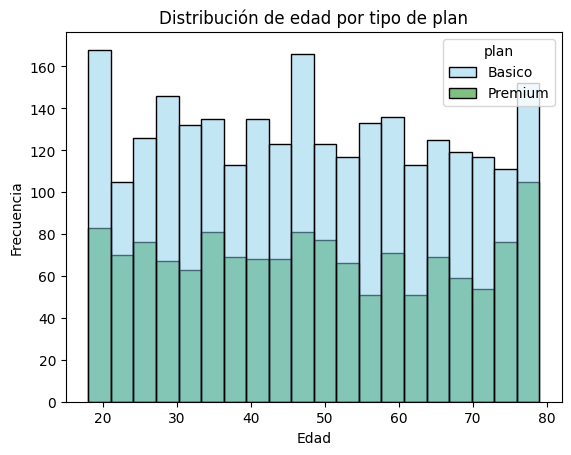

In [33]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)
plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución de edades es relativamente uniforme y no presenta un sesgo muy marcado.
- La mayoría de usuarios de ambos planes se concentra entre los 20 y 80 años.
- No se observa una diferencia importante entre usuarios Básico y Premium respecto a la edad.

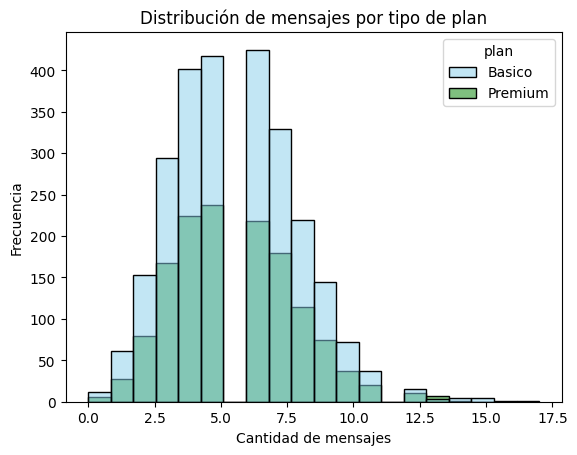

In [34]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)
plt.title('Distribución de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución está sesgada a la derecha porque existen pocos usuarios que envían muchos mensajes.
- La mayoría de usuarios envía entre 3 y 8 mensajes.
- Los usuarios Premium muestran una ligera tendencia a enviar más mensajes que los usuarios Básico.

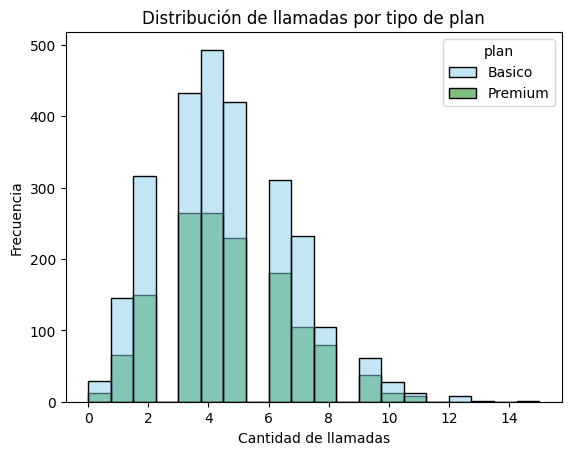

In [35]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)
plt.title('Distribución de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución sesgada a la derecha, ya que pocos usuarios realizan muchas llamadas.
- La mayoría de usuarios realiza entre 2 y 6 llamadas.
- Los usuarios Premium muestran una ligera tendencia a realizar más llamadas que los usuarios Básico.

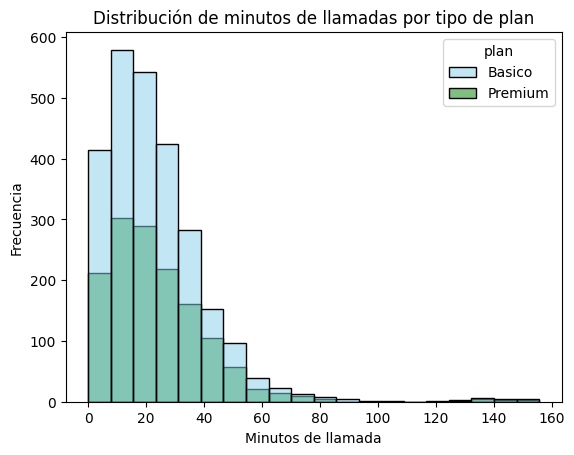

In [36]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)
plt.title('Distribución de minutos de llamadas por tipo de plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución presenta un fuerte sesgo a la derecha debido a algunos usuarios con muchos minutos acumulados.
- La mayoría de usuarios utiliza pocos minutos de llamada.
- Los usuarios Premium parecen acumular más minutos de llamada en comparación con los usuarios Básico.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

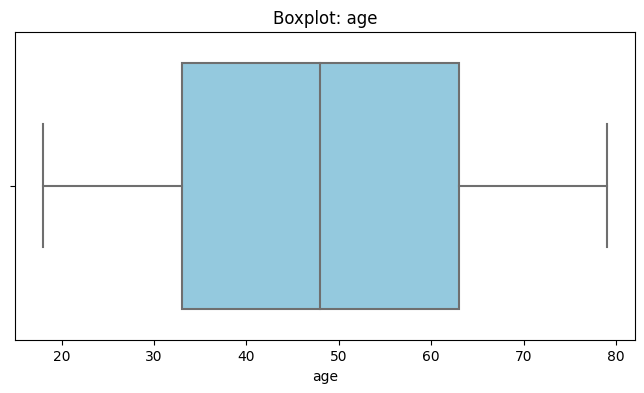

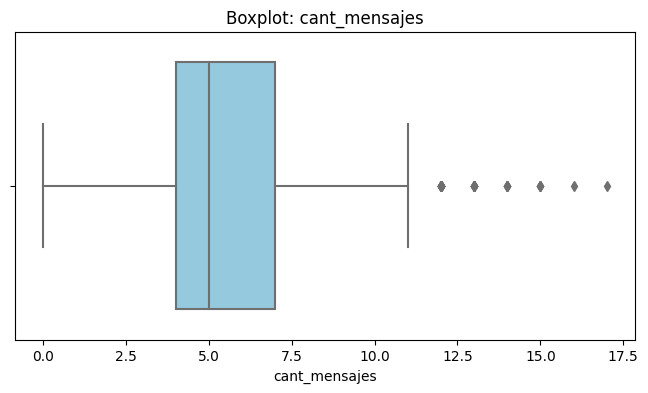

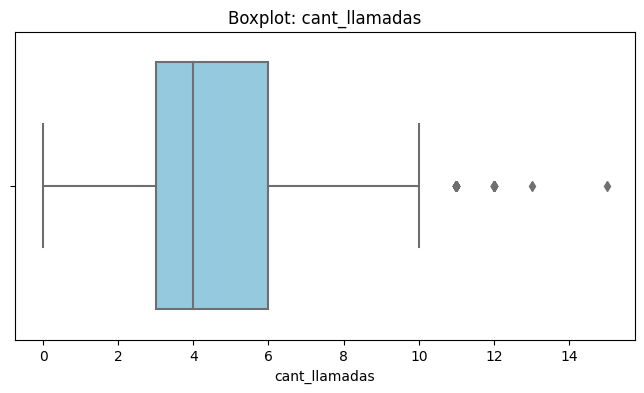

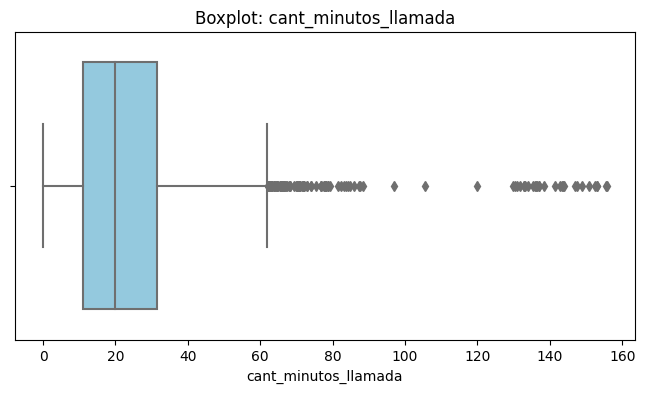

In [37]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: no presenta outliers visibles; la distribución de edades se mantiene dentro de rangos normales
- cant_mensajes: presenta algunos outliers altos, ya que existen usuarios que envian muchos más mensajes que la mayoria
- cant_llamadas: presenta algunos outliers en valores altos, indicando usuarios con una cantidad de llamadas superior al comportamiento típico
- cant_minutos_llamada: presenta una gran cantidad de outliers hacia la derecha, lo que indica usuarios con muchos minutos acumulados de llamadas en comparacion con la mayoria

In [38]:
# Calcular límites con el método IQR
columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 -Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f'nColumna: {col}')
    print(f'Q1: {Q1}')
    print(f'Q3: {Q3}')
    print(f'IQR: {IQR}')
    print(f'Limite superior: {limite_superior}')
    print(f'Max real: {user_profile[col].max()}')



nColumna: cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Limite superior: 11.5
Max real: 17.0
nColumna: cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Limite superior: 10.5
Max real: 15.0
nColumna: cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Limite superior: 61.8575
Max real: 155.69


In [39]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Se recomienda mantener los outliers, ya que representan usuarios con una actividad de mensajeria mas alta de lo normal, pero aun dentro de los valores posibles y realistas
- cant_llamadas: mantener o no outliers, porqué? Se recomienda mantener los outliers porque los valores maximos observados son coherentes con el comportamiento de algunos usuarios intensivos y no parecen errores de captura
- cant_minutos_llamada: mantener o no outliers, porqué? Se recomienda mantener los outliers, ya que aunque existen usuarios con muchos minutos acumulados, estos pueden corresponder a usuarios con uso intensivo del servicio. No se observan valores imposibles o inconsistentes

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [40]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

In [41]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
# Crear columna grupo_edad
user_profile['grupo_edad'] =np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

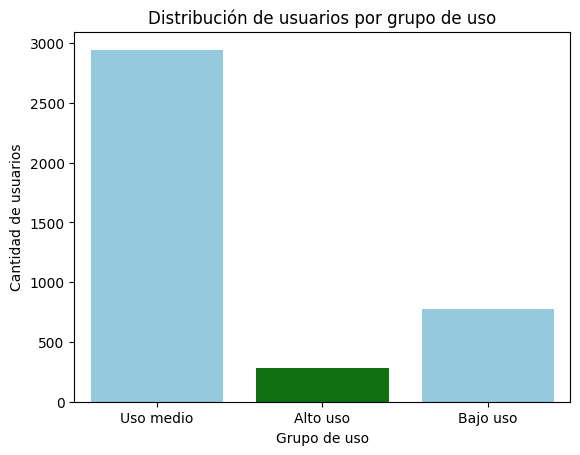

In [44]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue', 'green'])
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

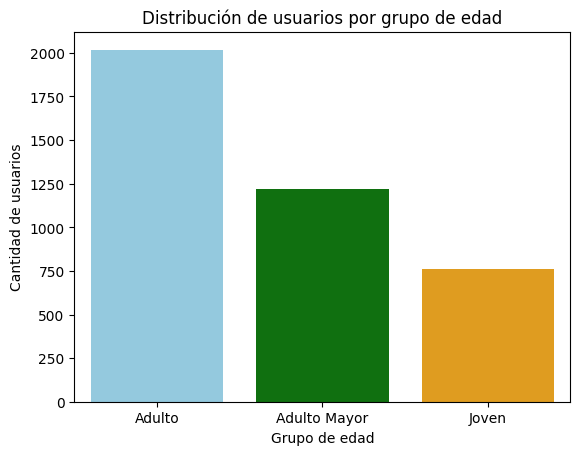

In [46]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue', 'green', 'orange'])
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

Durante la etapa de limpieza y exploración de datos se identificaron diversos problemas de calidad. En la columna `age` se encontraron valores sentinel (-999), los cuales fueron reemplazados por la mediana para evitar distorsiones en el análisis. En la columna `city` aparecieron registros con “?” que fueron tratados como valores nulos. Además, en la columna `reg_date` se detectaron 40 fechas futuras correspondientes al año 2026, aunque el dataset solo contempla información hasta 2024, por lo que dichas fechas se marcaron como nulas (`NA`). También se identificaron valores nulos en `duration` y `length`, los cuales dependen del tipo de registro (`call` o `text`), confirmando un patrón MAR (Missing At Random), por lo que se decidió mantenerlos como nulos.

Respecto a la segmentación de clientes, se identificaron tres grupos de uso: “Bajo uso”, “Uso medio” y “Alto uso”. La mayor parte de los usuarios pertenece al grupo de “Uso medio”, lo que indica que la mayoría tiene un consumo moderado de llamadas y mensajes. En cuanto a la edad, el grupo predominante es el de “Adultos”, seguido por “Adultos Mayores”, mientras que los usuarios jóvenes representan la menor proporción del dataset.

Los segmentos más valiosos para ConectaTel parecen ser los usuarios de “Uso medio” y “Alto uso”, ya que generan una mayor actividad dentro de la plataforma. Especialmente los usuarios de alto uso podrían representar clientes estratégicos para planes premium o paquetes con beneficios adicionales, debido a su alta frecuencia de llamadas y mensajes.

En el análisis de outliers se detectaron valores extremos en `cant_mensajes`, `cant_llamadas` y principalmente en `cant_minutos_llamada`. Sin embargo, los máximos observados (17 mensajes, 15 llamadas y 155.69 minutos) siguen siendo valores realistas y coherentes con usuarios intensivos, por lo que se decidió conservarlos. Estos outliers sugieren que existe un grupo reducido de clientes con un comportamiento de uso significativamente mayor al promedio.

Como recomendación de negocio, ConectaTel podría diseñar planes personalizados según los segmentos detectados. Para usuarios de bajo uso, podrían ofrecerse planes económicos con beneficios limitados. Para los usuarios de uso medio y alto, sería conveniente desarrollar paquetes con mayores beneficios en llamadas y mensajes, programas de fidelización o promociones premium. Asimismo, el análisis por edad puede ayudar a crear campañas dirigidas específicamente a adultos y adultos mayores, quienes representan la mayor parte de los clientes.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron valores sentinel en la columna age con el valor -999, los cuales fueron reemplazados por la mediana para evitar afectar el análisis estadístico.

- En la columna city se encontraron registros con "?", los cuales fueron tratados como valores nulos (NA).

- Se detectaron 40 registros con fechas futuras en reg_date correspondientes al año 2026, aunque el dataset solo contiene información válida hasta 2024. Estas fechas fueron marcadas como nulas.

- En las columnas duration y length se encontraron valores nulos dependientes de la variable type, confirmando un patrón MAR (Missing At Random), por lo que se mantuvieron como nulos.

🔍 **Segmentos por Edad**
- El grupo predominante corresponde a los usuarios “Adultos”, siendo el segmento más representativo dentro del dataset.

- Los “Adultos Mayores” representan una proporción importante de clientes, mientras que el grupo “Joven” es el menos frecuente.

- La distribución de edades no presenta outliers significativos y muestra un comportamiento relativamente equilibrado.


📊 **Segmentos por Nivel de Uso**
- La mayoría de los usuarios pertenece al segmento de “Uso medio”, indicando un comportamiento moderado en llamadas y mensajes.

- El grupo “Bajo uso” también tiene una presencia considerable, mientras que los usuarios de “Alto uso” representan la menor proporción.

- Se detectaron outliers en cant_mensajes, cant_llamadas y principalmente en cant_minutos_llamada, aunque los valores máximos observados son coherentes con usuarios intensivos y no parecen errores.


➡️ Esto sugiere que ...
- La mayor oportunidad comercial para ConectaTel se encuentra en los usuarios de “Uso medio”, ya que representan la mayoría de los clientes y podrían convertirse en usuarios de mayor consumo mediante estrategias de fidelización.

- Los usuarios de “Alto uso” son clientes valiosos para planes premium o paquetes especializados debido a su alta actividad.

- La presencia importante de adultos y adultos mayores sugiere que las campañas y planes deben enfocarse en simplicidad, estabilidad del servicio y beneficios en comunicación.


💡 **Recomendaciones**
- Diseñar planes diferenciados según el nivel de uso detectado: económicos para bajo uso y premium para usuarios intensivos.

- Implementar promociones dirigidas al segmento de “Uso medio” para incentivar un mayor consumo.

- Crear estrategias comerciales específicas para adultos y adultos mayores, quienes representan la mayor parte de los clientes.

- Mantener monitoreo continuo de valores atípicos y calidad de datos para evitar inconsistencias futuras.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`